# Analyse exploratoire - Dataset Endométriose

Ce notebook explore le dataset synthétique d'endométriose (10 000 observations, 7 variables) pour comprendre la distribution des variables, les corrélations et les relations avec le diagnostic.

**Variables :**
- `Age` : âge (18-50 ans)
- `Menstrual_Irregularity` : irrégularité menstruelle (0/1)
- `Chronic_Pain_Level` : niveau de douleur chronique (0-10)
- `Hormone_Level_Abnormality` : anomalie hormonale (0/1)
- `Infertility` : infertilité (0/1)
- `BMI` : indice de masse corporelle (15-40)
- `Diagnosis` : cible - endométriose (0/1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/structured_endometriosis_data.csv")
df.head()

,Age,Menstrual_Irregularity,Chronic_Pain_Level,Hormone_Level_Abnormality,Infertility,BMI,Diagnosis
0,24,1,8.361531,0,0,19.451314,0
1,37,1,4.995508,0,0,22.388436,0
2,46,1,3.363996,1,0,21.320443,0
3,32,1,5.246037,0,0,20.177715,1
4,28,1,3.898932,1,0,23.538103,1


## 1. Aperçu général

In [2]:
print(f"Shape : {df.shape}")
print(f"\nValeurs manquantes :\n{df.isna().sum()}")
print(f"\nDoublons : {df.duplicated().sum()}")

Shape : (10000, 7)

Valeurs manquantes :
Age                          0
Menstrual_Irregularity       0
Chronic_Pain_Level           0
Hormone_Level_Abnormality    0
Infertility                  0
BMI                          0
Diagnosis                    0
dtype: int64

Doublons : 0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        10000 non-null  int64  
 1   Menstrual_Irregularity     10000 non-null  int64  
 2   Chronic_Pain_Level         10000 non-null  float64
 3   Hormone_Level_Abnormality  10000 non-null  int64  
 4   Infertility                10000 non-null  int64  
 5   BMI                        10000 non-null  float64
 6   Diagnosis                  10000 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 547.0 KB


In [4]:
df.describe()

,Age,Menstrual_Irregularity,Chronic_Pain_Level,Hormone_Level_Abnormality,Infertility,BMI,Diagnosis
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,33.692300,0.697500,5.030619,0.591100,0.298300,23.052865,0.407900
std,9.205308,0.459364,1.983955,0.491655,0.457535,3.891615,0.491469
min,18.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000
25%,26.000000,0.000000,3.671697,0.000000,0.000000,20.329327,0.000000
50%,34.000000,1.000000,5.035825,1.000000,0.000000,23.036315,0.000000
75%,42.000000,1.000000,6.396854,1.000000,1.000000,25.712923,1.000000
max,49.000000,1.000000,10.000000,1.000000,1.000000,37.146127,1.000000


## 2. Distribution de la variable cible

/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94490/3519596730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Diagnosis", data=df, ax=ax[0], palette="viridis")
/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94490/3519596730.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(["Pas d'endométriose", "Endométriose"])


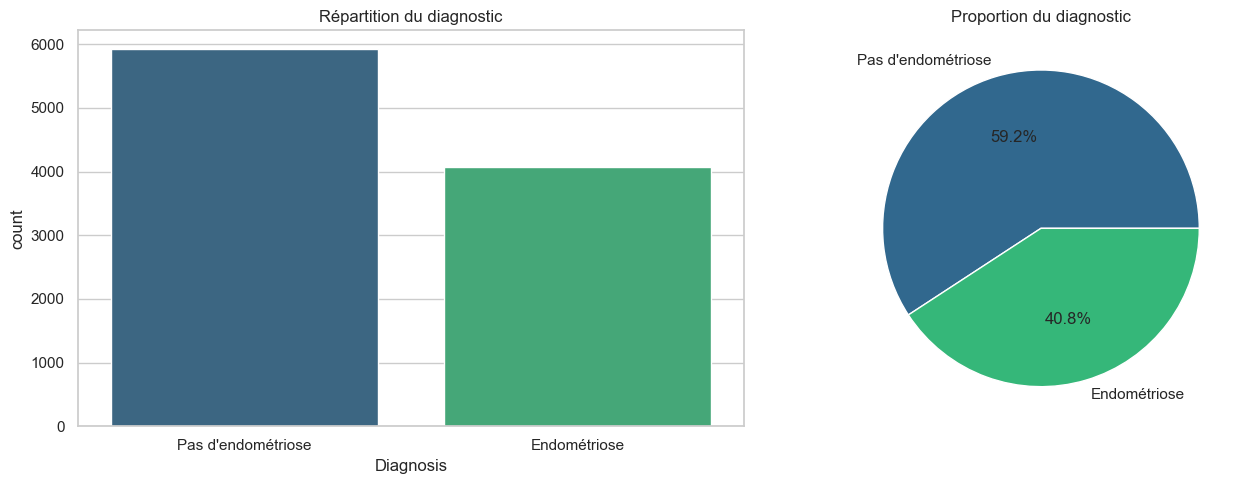

Distribution : 
Diagnosis
0    59.21
1    40.79
Name: proportion, dtype: float64


In [5]:
target_counts = df["Diagnosis"].value_counts()
target_pct = df["Diagnosis"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x="Diagnosis", data=df, ax=ax[0], palette="viridis")
ax[0].set_title("Répartition du diagnostic")
ax[0].set_xticklabels(["Pas d'endométriose", "Endométriose"])

ax[1].pie(target_counts, labels=["Pas d'endométriose", "Endométriose"], autopct="%1.1f%%", colors=sns.color_palette("viridis", 2))
ax[1].set_title("Proportion du diagnostic")
plt.tight_layout()
plt.show()

print(f"Distribution : \n{target_pct.round(2)}")

## 3. Distribution des variables numériques

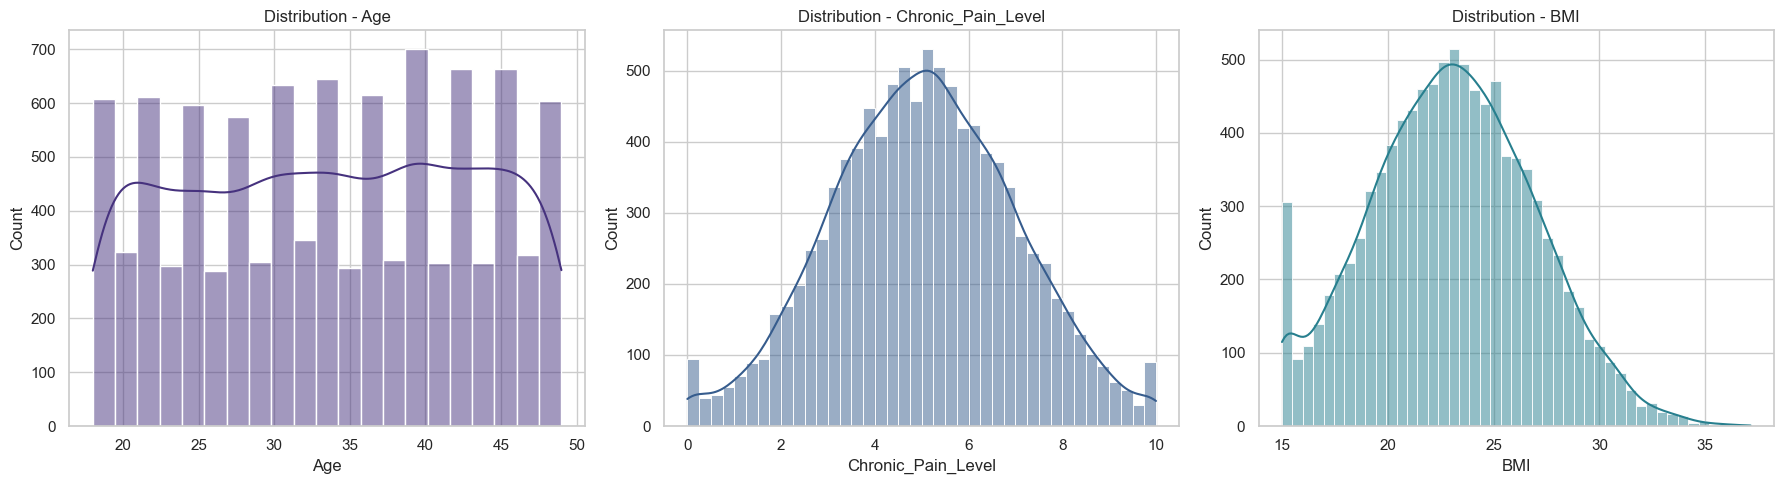

In [6]:
numerical = ["Age", "Chronic_Pain_Level", "BMI"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(numerical):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("viridis")[i])
    axes[i].set_title(f"Distribution - {col}")
plt.tight_layout()
plt.show()

/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94490/3550100955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Diagnosis", y=col, data=df, ax=axes[i], palette="viridis")
/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94490/3550100955.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Non", "Oui"])
/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94490/3550100955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Diagnosis", y=col, data=df, ax=axes[i], palette="viridis")
/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94490/3

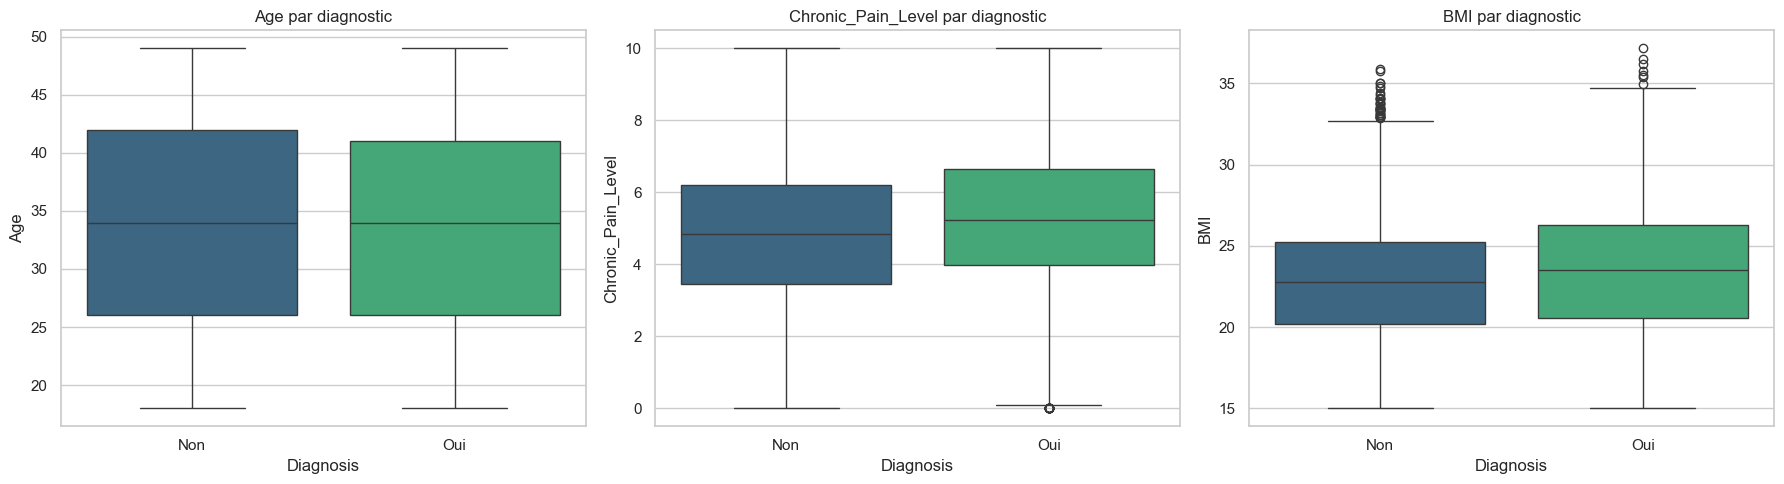

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(numerical):
    sns.boxplot(x="Diagnosis", y=col, data=df, ax=axes[i], palette="viridis")
    axes[i].set_title(f"{col} par diagnostic")
    axes[i].set_xticklabels(["Non", "Oui"])
plt.tight_layout()
plt.show()

## 4. Distribution des variables binaires

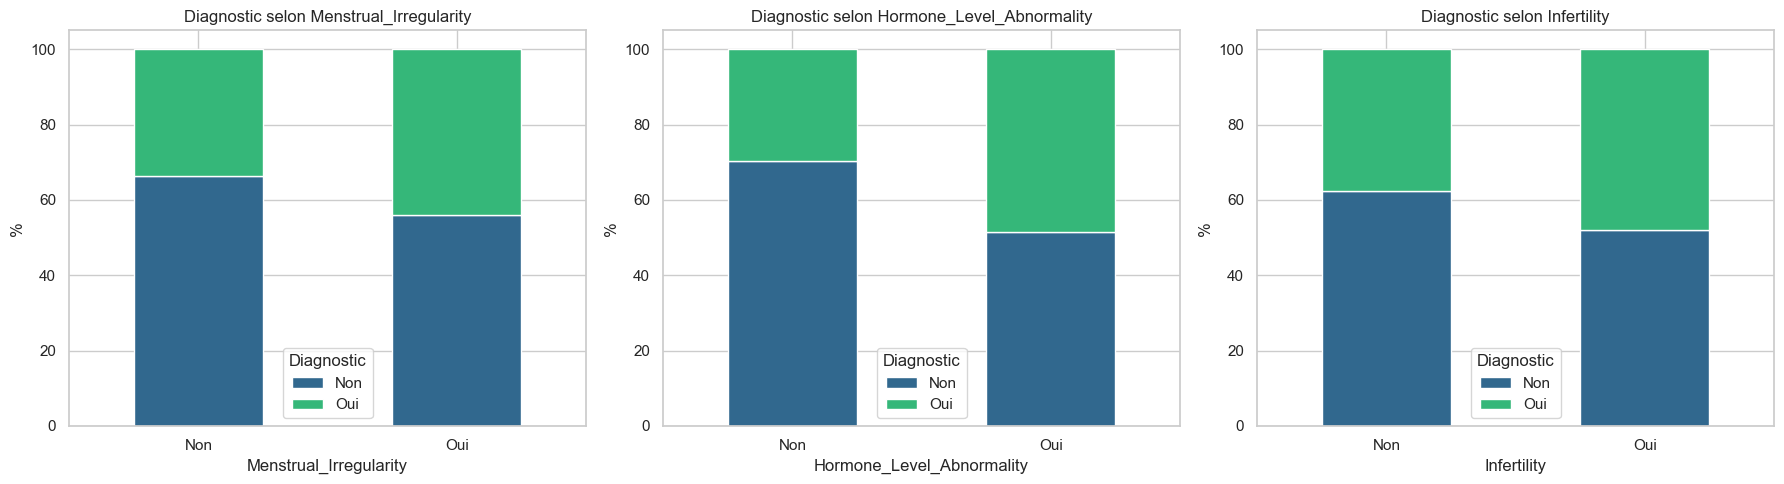

In [8]:
binary = ["Menstrual_Irregularity", "Hormone_Level_Abnormality", "Infertility"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(binary):
    ct = pd.crosstab(df[col], df["Diagnosis"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=sns.color_palette("viridis", 2))
    axes[i].set_title(f"Diagnostic selon {col}")
    axes[i].set_ylabel("%")
    axes[i].legend(["Non", "Oui"], title="Diagnostic")
    axes[i].set_xticklabels(["Non", "Oui"], rotation=0)
plt.tight_layout()
plt.show()

## 5. Matrice de corrélation

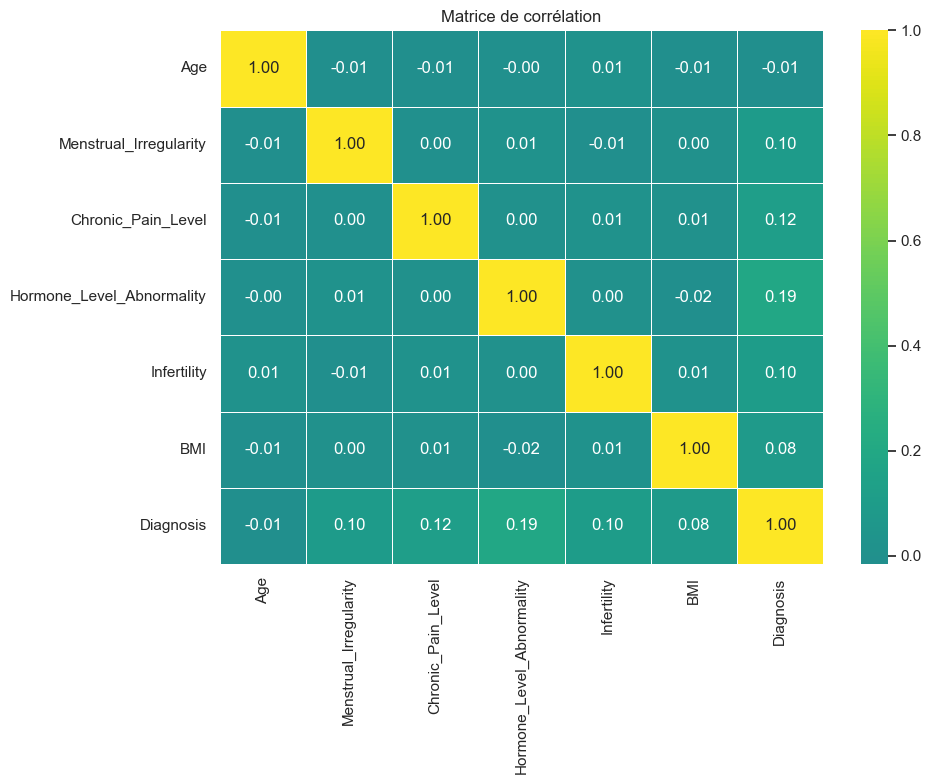

In [9]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5, center=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94490/4160929427.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette="viridis")


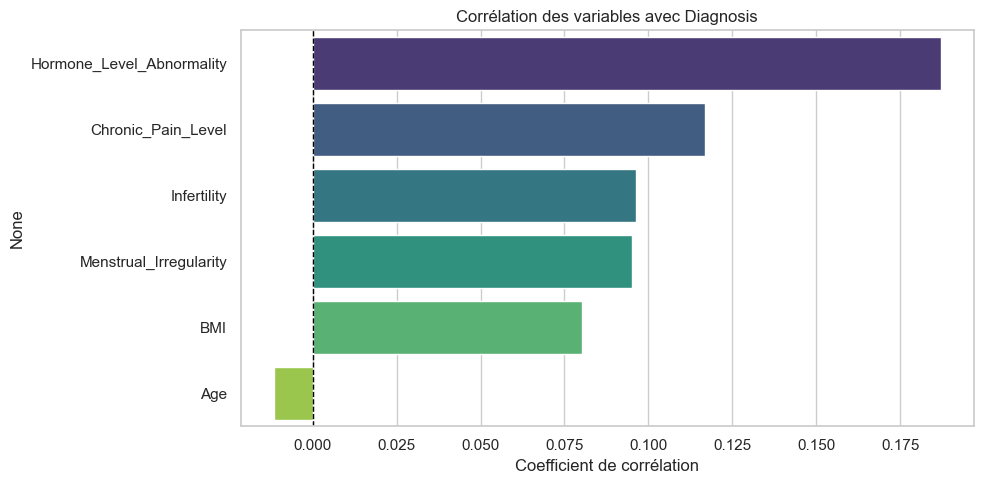

Hormone_Level_Abnormality    0.187039
Chronic_Pain_Level           0.116996
Infertility                  0.096172
Menstrual_Irregularity       0.095197
BMI                          0.080310
Age                         -0.011559
Name: Diagnosis, dtype: float64


In [10]:
target_corr = corr["Diagnosis"].drop("Diagnosis").sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="viridis")
plt.title("Corrélation des variables avec Diagnosis")
plt.xlabel("Coefficient de corrélation")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

print(target_corr)

## 6. Analyses bivariées approfondies

/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94490/999446671.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Diagnosis", y="Chronic_Pain_Level", data=df, palette="viridis")


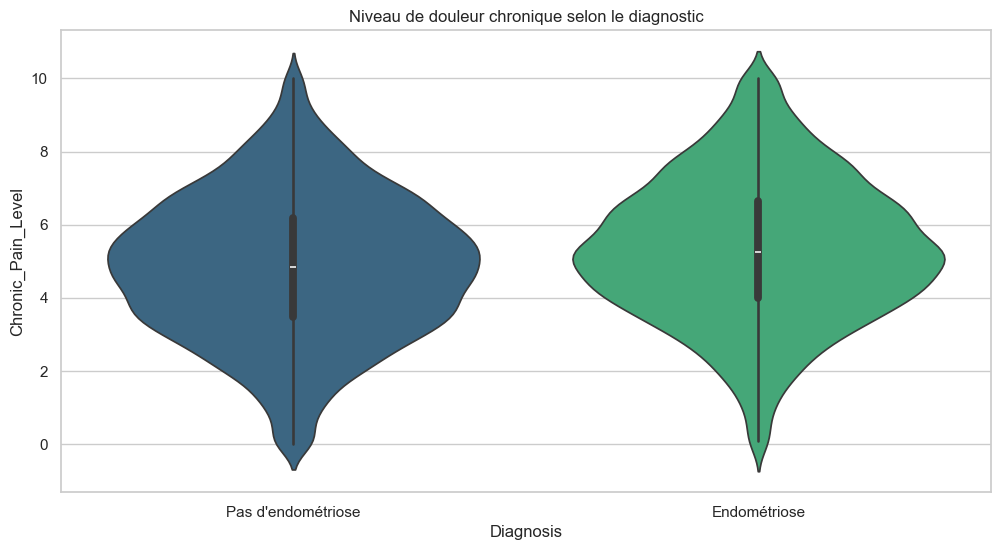

In [11]:
plt.figure(figsize=(12, 6))
sns.violinplot(x="Diagnosis", y="Chronic_Pain_Level", data=df, palette="viridis")
plt.title("Niveau de douleur chronique selon le diagnostic")
plt.xticks([0, 1], ["Pas d'endométriose", "Endométriose"])
plt.show()

/var/folders/kr/qn8bq3254gg0x4nt_l1gbpfc0000gn/T/ipykernel_94490/377848431.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_diag.index, y=age_diag.values, palette="viridis")


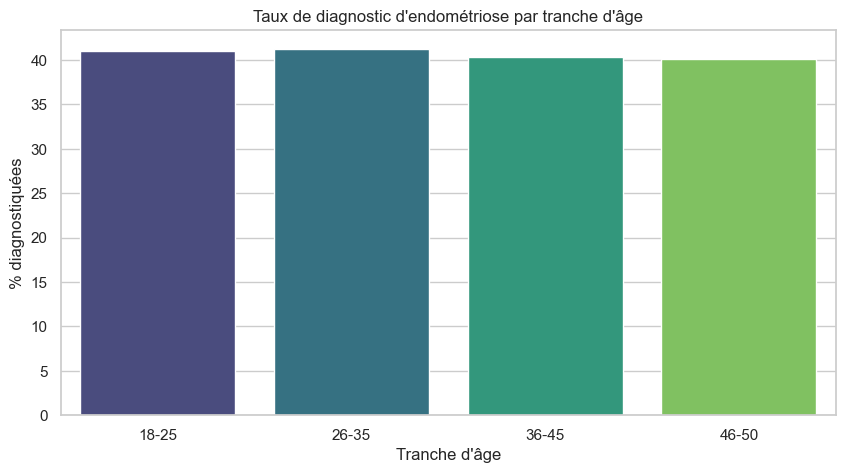

In [12]:
df["Age_Group"] = pd.cut(df["Age"], bins=[17, 25, 35, 45, 55], labels=["18-25", "26-35", "36-45", "46-50"])
age_diag = df.groupby("Age_Group", observed=True)["Diagnosis"].mean() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=age_diag.index, y=age_diag.values, palette="viridis")
plt.title("Taux de diagnostic d'endométriose par tranche d'âge")
plt.ylabel("% diagnostiquées")
plt.xlabel("Tranche d'âge")
plt.show()

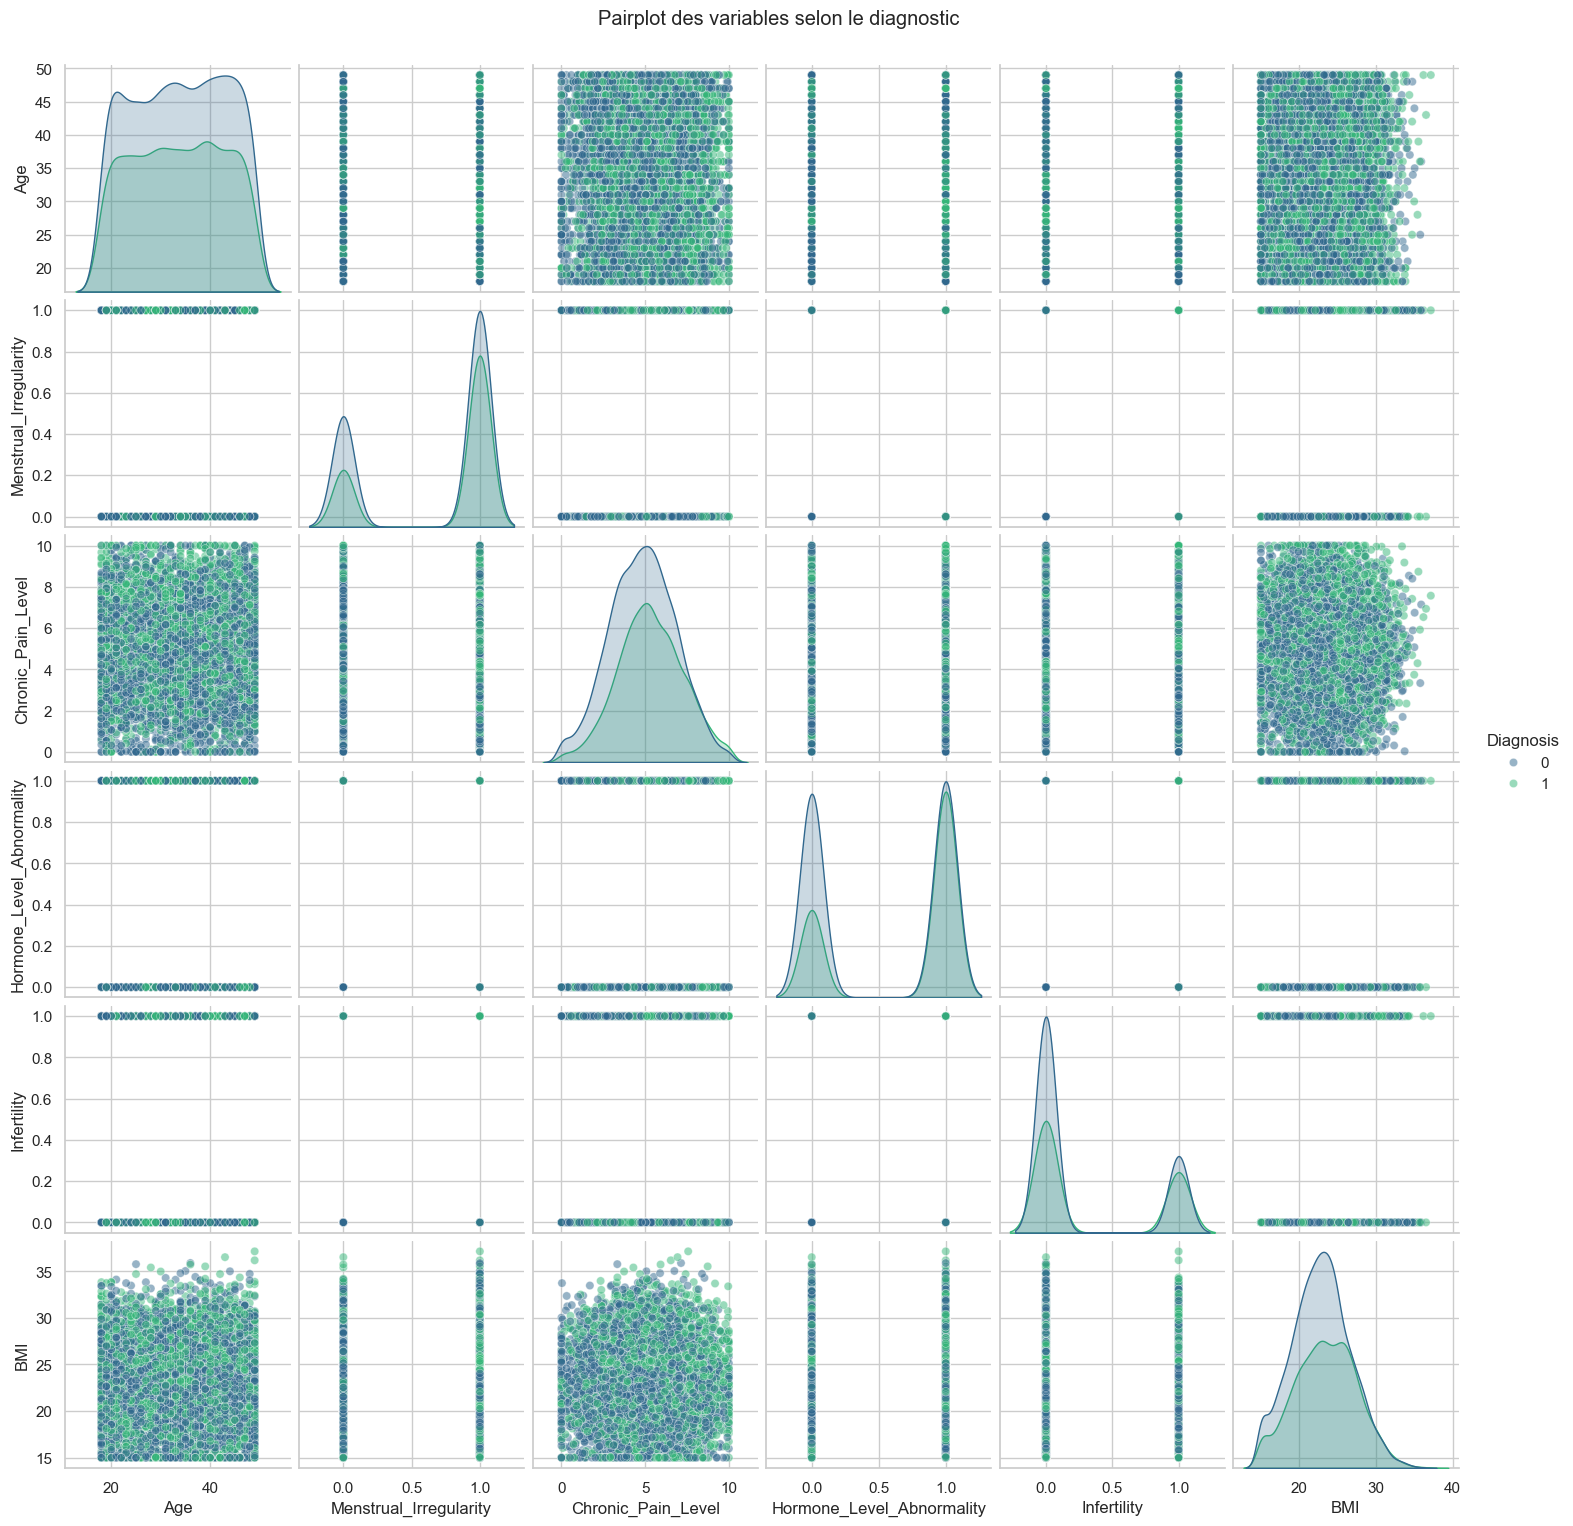

In [13]:
sns.pairplot(df.drop(columns=["Age_Group"]), hue="Diagnosis", palette="viridis", diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot des variables selon le diagnostic", y=1.02)
plt.show()

## 7. Synthèse

- Le dataset est propre (aucune valeur manquante, types cohérents).
- La variable la plus corrélée à `Diagnosis` est `Chronic_Pain_Level`, suivie des variables binaires symptomatiques.
- Les variables `Age` et `BMI` présentent une corrélation plus faible avec la cible.
- La classe est déséquilibrée, à prendre en compte lors de la modélisation (stratification du split, métriques adaptées).